# Downstream Evaluation: RankMe Evolution → Multilingual Performance

**Research question:** *Does the shape of the RankMe trajectory during pre-training predict downstream multilingual performance? Specifically: does the point where compression begins (onset) and how long it lasts (duration) correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)

### What this notebook does
1. **Phase identification** — detects two training phases from the RankMe curve: an *entropy-seeking* phase (RankMe ↑, the model builds richer representations) and a *compression-seeking* phase (RankMe ↓, the model specializes and compresses). For each phase, **onset** is the token count (in billions) where the phase begins, and **duration** is how many tokens it lasts. Works with `fuxi.csv` alone.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints. This marks the point where the model transitions from near-random guessing to genuinely solving the task. Requires downstream eval results.
3. **Correlation analysis** — Spearman + Pearson tests: *does an earlier or longer compression phase predict earlier or higher accuracy?* Computed separately per task (m-MMLU / XCOPA), never pooled across tasks.
4. **Plots** — RankMe trajectories, phase overlays (shaded regions drawn on the RankMe curve that visually mark where each phase occurs), dual-axis accuracy curves, and a correlation scatter per task.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [1]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_phases, compute_alpha_phases,
    compute_grokking,
    compute_correlations_table, compute_alpha_correlations_table,
    plot_rankme_phases, plot_overlay, plot_correlation_scatter, plot_rankme_last_scatter,
    plot_alpha_phases, plot_alpha_overlay, plot_alpha_correlation_scatter,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

> 🚨 **Set `MODEL` before running.** Change the variable in the next cell to `"fuxi"` or `"apertus"`. Do not run all cells without doing this — the CSV path, last layer, and model label all derive from that single variable.

`load_config()` automatically derives everything else — CSV paths, which layer to use for phase analysis, grokking detection parameters, and benchmark metadata (languages, random-chance baselines) loaded from `configs/benchmarks.yaml`.

In [2]:
MODEL = "fuxi_intermediate"   # ← "fuxi" or "apertus"

cfg = load_config(MODEL)
RANKME_CSV          = cfg["rankme_csv"]
MERGED_CSV          = cfg["merged_csv"]
LAYER               = cfg["layer"]
AGGREGATION         = cfg["aggregation"]
MODEL_LABEL         = cfg["model_label"]
GROKKING_THRESHOLD  = cfg["grokking_threshold"]
GROKKING_MIN_CONSEC = cfg["grokking_min_consec"]
RANDOM_CHANCE       = cfg["random_chance"]
TASK_LANGUAGES      = cfg["task_languages"]
PLOTS_DIR           = cfg["plots_dir"]

print(f"Model: {MODEL_LABEL}  |  Layer: {LAYER}  |  Aggregation: {AGGREGATION}")

Model: FuxiTranyu-8B (intermediate)  |  Layer: layer_29  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi.csv` / `apertus.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_29`, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run.

- **`fuxi_merged.csv` / `apertus_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Only contains the checkpoints that have been evaluated. Used for grokking detection, correlation analysis, and overlay plots.

The phase plots use the full geometry data (all checkpoints). The accuracy-based plots use only the evaluated checkpoints.

In [3]:
df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(RANKME_CSV, LAYER, AGGREGATION)
df_eval, EVAL_AVAILABLE = load_eval_data(MERGED_CSV)

Loaded RankMe: 44,460 rows — 57 checkpoints, 13 languages
Working slice : layer_29, agg=last → 741 rows
Loaded eval: 514 records — 2 task(s), 57 checkpoint(s)


## Phase Identification

The RankMe curve is split into two phases by locating its global peak:

- **Entropy-seeking** — from the first observed checkpoint to the peak (RankMe ↑). The model is building richer, more diverse representations.
- **Compression-seeking** — from the peak to the end of training (RankMe ↓). The model specialises and compresses its representations.

For each phase, **onset** is the token count where it begins and **duration** is how long it lasts. All token values are in **billions (B)**.

A phase is `NaN` when it cannot be observed in the available data:
- **Entropy NaN** — the peak is at the very first checkpoint we have, meaning the entropy-seeking phase either happened before training began or before the earliest checkpoint recorded. This is the case for FuxiTranyu-8B, where RankMe is highest at 10B tokens and decreases from there.
- **Compression NaN** — RankMe never falls after the peak, so no compression phase is detected.

In [4]:
df_phases = compute_phases(df_layer, checkpoints_all, token_counts)

display_cols = {
    "language":                    "language",
    "peak_tokens":                 "peak (B)",
    "entropy_onset_tokens":        "entropy onset (B)",
    "entropy_duration_tokens":     "entropy duration (B)",
    "compression_onset_tokens":    "compression onset (B)",
    "compression_duration_tokens": "compression duration (B)",
    "rankme_first":                "RankMe first ckpt",
    "rankme_last":                 "RankMe last ckpt",
    "rankme_decline_rate":         "decline rate (1/B)",
}
print(df_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))

  language  peak (B)  entropy onset (B)  entropy duration (B)  compression onset (B)  compression duration (B)  RankMe first ckpt  RankMe last ckpt  decline rate (1/B)
    Arabic      10.0                NaN                   NaN                   10.0                     583.0           326.5751          195.7686            0.224368
   Chinese      10.0                NaN                   NaN                   10.0                     583.0           348.8359           66.8863            0.483619
   English      10.0                NaN                   NaN                   10.0                     583.0           576.6230          271.6560            0.523099
    French      10.0                NaN                   NaN                   10.0                     583.0           380.4108          191.5611            0.323927
    German      10.0                NaN                   NaN                   10.0                     583.0           446.8770          219.0054            0

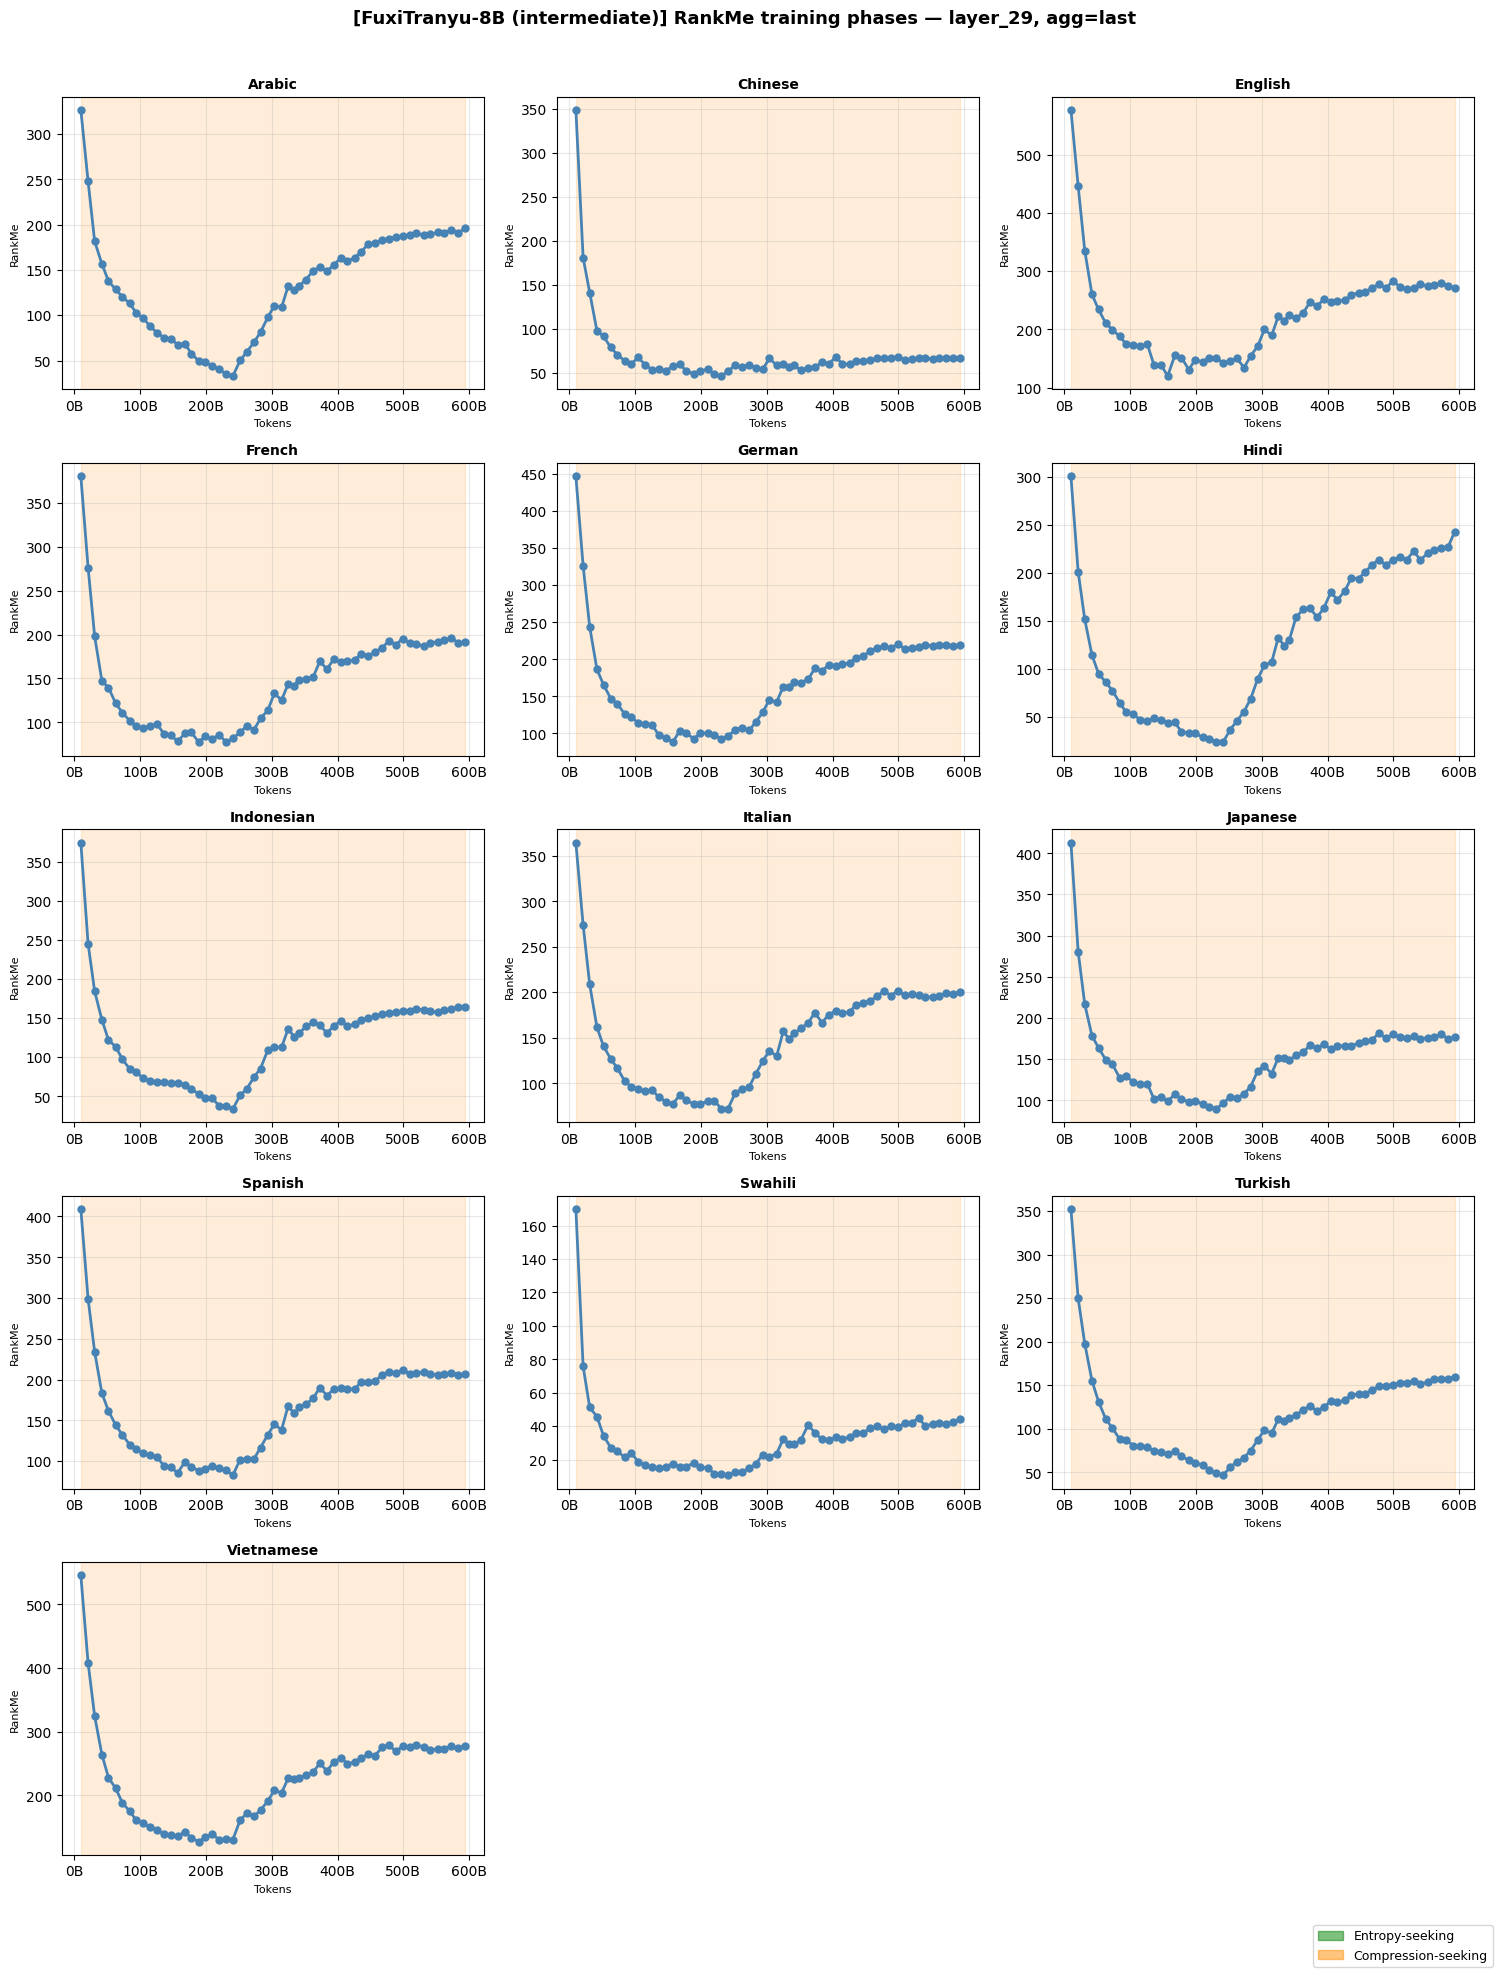

Saved: plots/rankme_phases.png


In [5]:
plot_rankme_phases(df_layer, df_phases, checkpoints_all, token_counts,
                   langs_sorted, MODEL_LABEL, LAYER, AGGREGATION, PLOTS_DIR)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task:

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all evaluated checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any evaluated checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [6]:
if EVAL_AVAILABLE:
    df_grokking = compute_grokking(df_eval, TASK_LANGUAGES, RANDOM_CHANCE,
                                   threshold=GROKKING_THRESHOLD,
                                   min_consecutive=GROKKING_MIN_CONSEC)
    display_cols = {
        "task":            "task",
        "language":        "language",
        "grokking_tokens": "grokking onset (B)",
        "peak_tokens":     "peak (B)",
        "peak_accuracy":   "peak accuracy",
        "random_chance":   "random chance",
    }
    print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
else:
    df_grokking = pd.DataFrame()
    print("[INFO] No eval data — run submit_eval.sh + merge_results.py first.")

  task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
m_mmlu    English                 NaN     115.0       0.272590           0.25
m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
m_mmlu     German                 NaN     199.0       0.274928           0.25
m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
m_mmlu    Italian                 NaN     199.0       0.271587           0.25
m_mmlu     Arabic                 NaN     126.0       0.272741           0.25
m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
 xcopa    Chinese               325.0     426.0       0.664000           0.50
 xcopa    Italian               241.0     520.0       0.718000           0.50
 xcopa Vietnamese               126.0     436.0       0.736000           0.50
 xcopa    Turkish                 NaN     593.0       0.644000  

## Correlation Analysis

Tests whether RankMe phase geometry predicts downstream performance. Five predictors are tested against two outcomes, separately per task:

**Timing-based (may have zero variance if all languages peak at the same checkpoint):**
- **Compression onset (B)** — how early the compression phase begins.
- **Compression duration (B)** — how long the compression phase lasts.

**Magnitude-based (vary across languages regardless of when the peak occurs):**
- **RankMe at first ckpt** — representation richness at the start of training.
- **RankMe at last ckpt** — representation richness at the end of training.
- **Rate of RankMe decline (1/B)** — (RankMe[first] − RankMe[last]) / total training tokens; how aggressively the model compresses each language's representations.

Outcomes:
- **Grokking onset (B)** — when accuracy first crosses the threshold.
- **Peak accuracy** — highest accuracy across all evaluated checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [7]:
if EVAL_AVAILABLE and not df_grokking.empty:
    df_correlations = compute_correlations_table(df_grokking, df_phases)
    print(df_correlations.to_string(index=False))
else:
    df_correlations = pd.DataFrame()
    print("[INFO] Skipping correlation analysis — no eval data available.")

  task                predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu        Compression onset (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu        Compression onset (B)      Peak accuracy            8         NaN         NaN        NaN        NaN
m_mmlu     Compression duration (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu     Compression duration (B)      Peak accuracy            8         NaN         NaN        NaN        NaN
m_mmlu         RankMe at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu         RankMe at first ckpt      Peak accuracy            8      0.5000      0.2070     0.3796     0.3537
m_mmlu          RankMe at last ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu          RankMe at last ckpt      Peak accuracy            8     -0.2857      0.4

The scatter plot below visualises compression onset vs peak accuracy (one panel per task) with labeled points per language and a linear regression line.

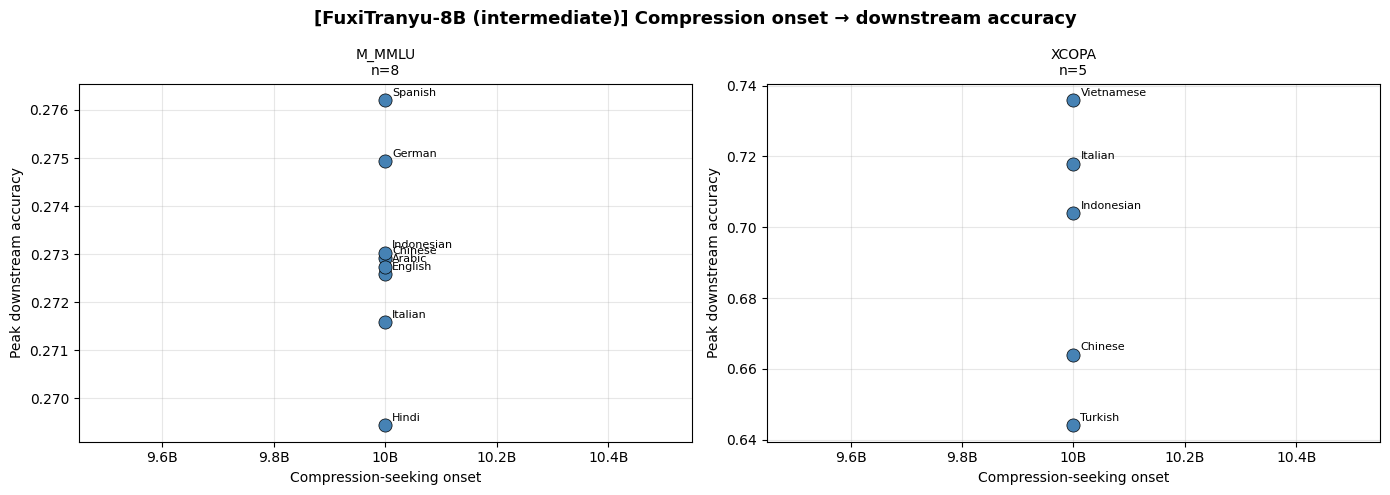

Saved: plots/correlation_scatter.png


In [8]:
if EVAL_AVAILABLE and not df_correlations.empty:
    plot_correlation_scatter(df_grokking, df_phases, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping correlation scatter — no eval data available.")

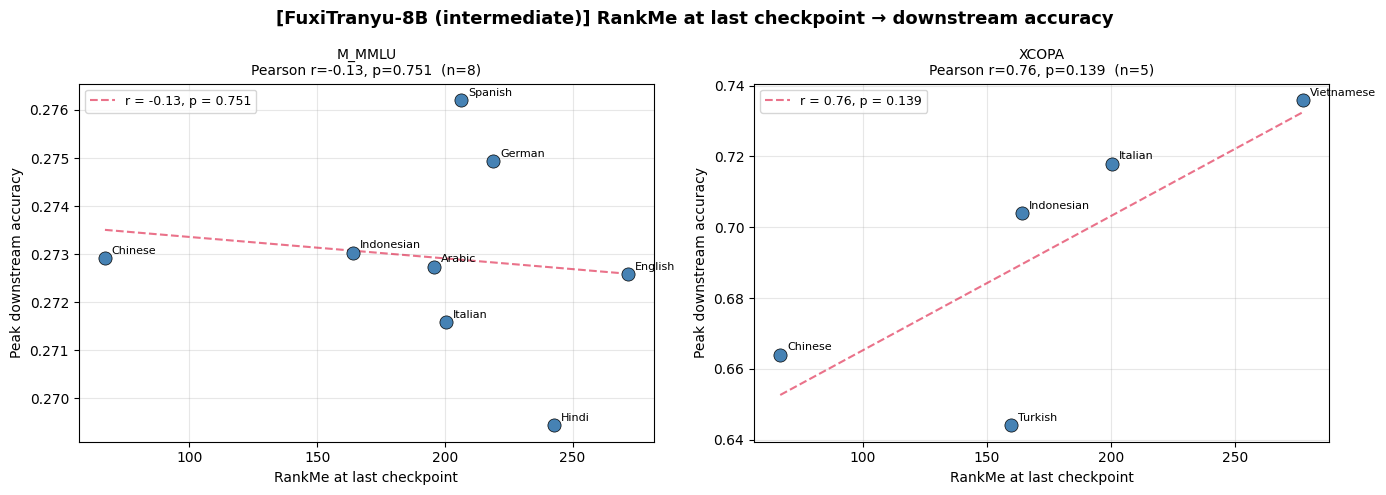

Saved: plots/rankme_last_scatter.png


In [9]:
if EVAL_AVAILABLE and not df_correlations.empty:
    plot_rankme_last_scatter(df_grokking, df_phases, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping RankMe last checkpoint scatter — no eval data available.")

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language that appears in both the RankMe data and the evaluation results. Each panel shows two y-axes:

- **Left axis (blue)** — RankMe trajectory across all checkpoints, showing the full geometry evolution during pre-training.
- **Right axis (red, dashed)** — downstream accuracy at the evaluated checkpoints only. The axis always spans 0 to 1.

The shaded regions mark the two training phases (green = entropy-seeking, orange = compression-seeking). The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — it is absent when grokking was not detected (accuracy never exceeded the threshold for 2 consecutive checkpoints).

These plots let you visually inspect whether accuracy rises during or after the compression phase, and whether grokking coincides with any particular point in the RankMe trajectory.

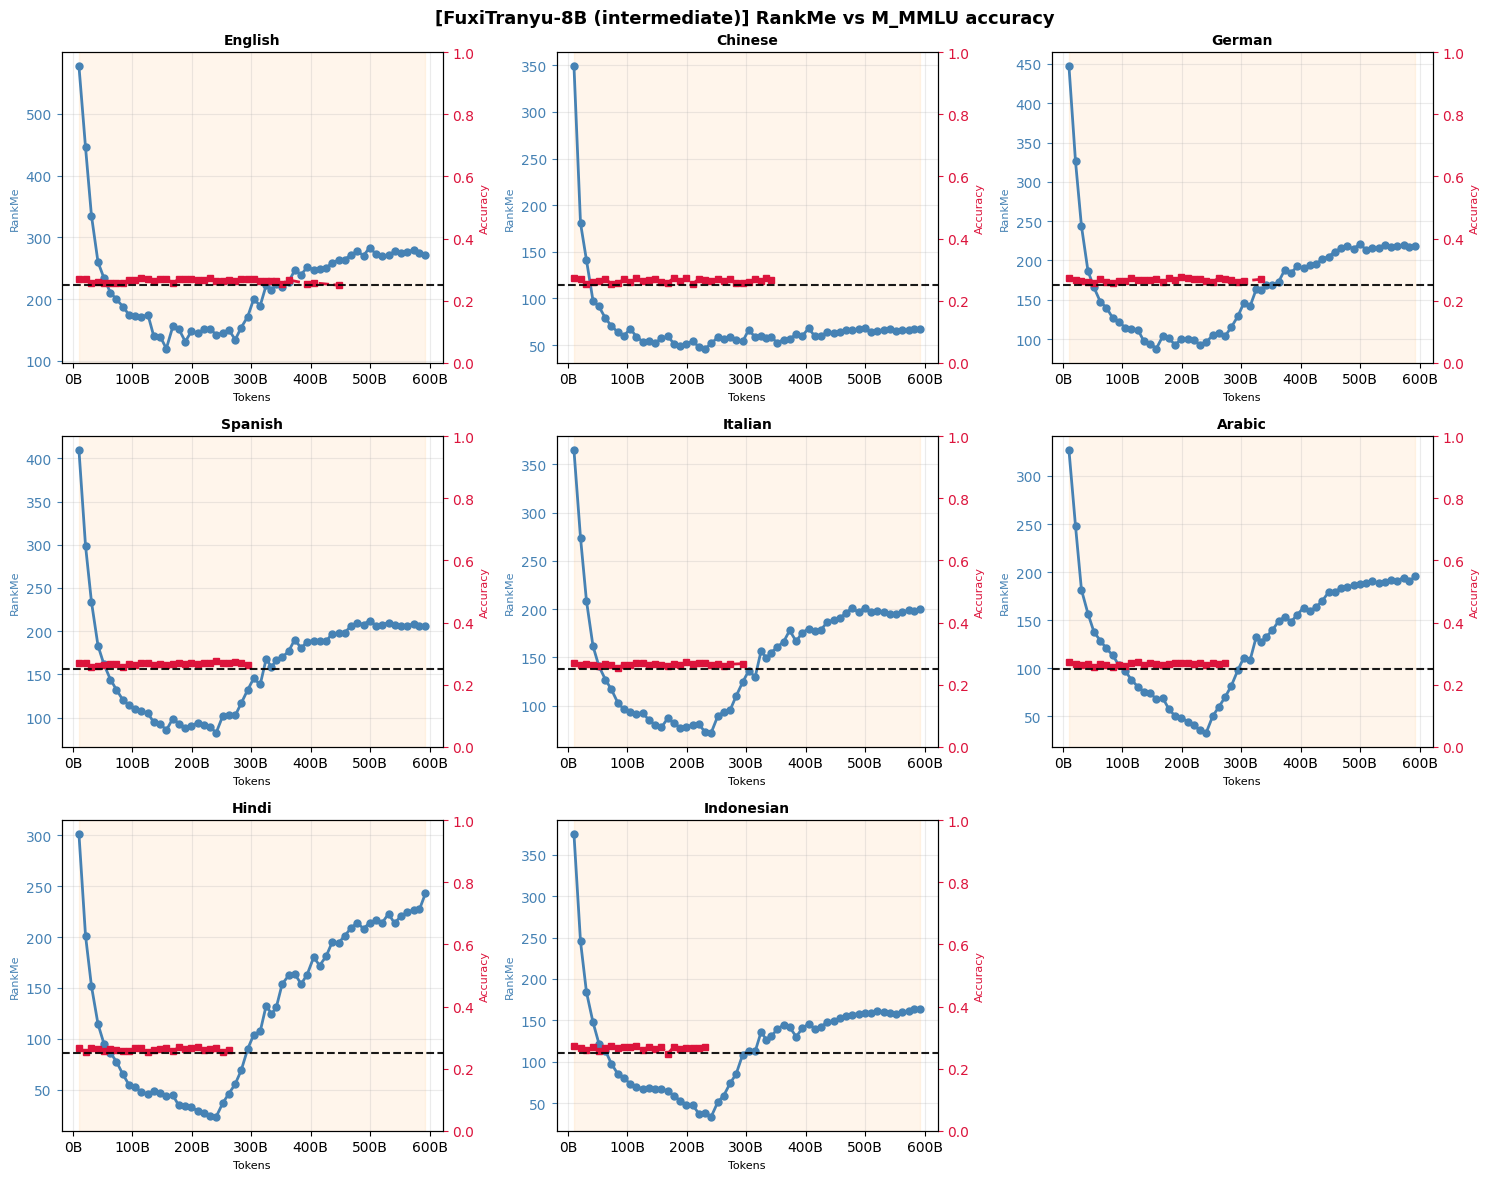

Saved: plots/overlay_m_mmlu.png


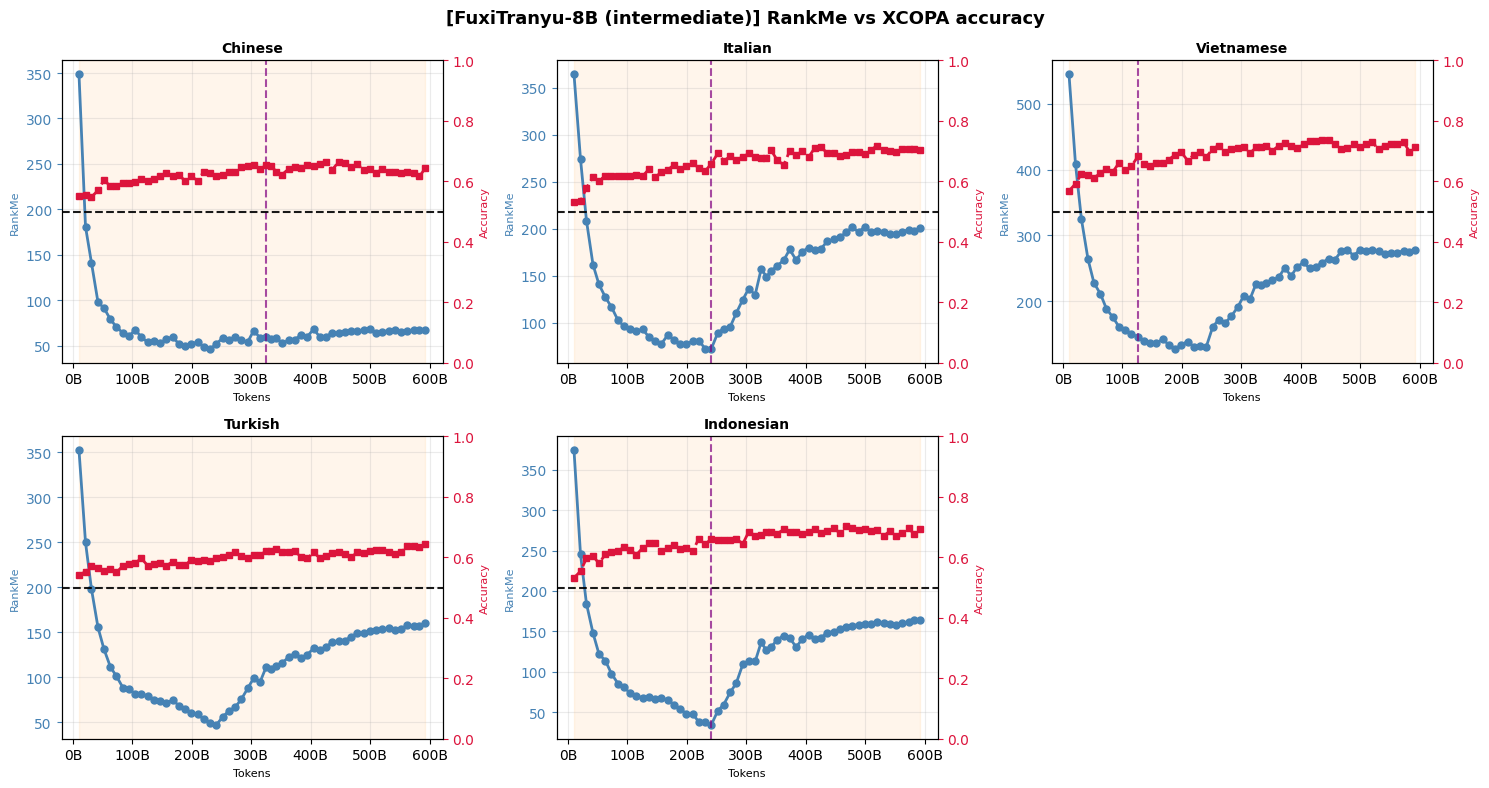

Saved: plots/overlay_xcopa.png


In [10]:
if EVAL_AVAILABLE:
    plot_overlay(df_eval, df_layer, df_phases, df_grokking, TASK_LANGUAGES, RANDOM_CHANCE,
                 checkpoints_all, token_counts, langs_sorted, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping overlay plots — run evaluate.py first.")

## RankMe Findings

**Phase structure (RankMe, all 13 languages)**

- RankMe peaks at the very first checkpoint (10B tokens) and declines throughout training for every language — the compression phase onset is synchronised across all languages. Because there is zero variance in the onset, timing-based correlations (compression onset, duration) are all undefined.
- The magnitude of RankMe varies substantially across languages both at the start (169–577) and at the end (44–278) of training, providing a meaningful cross-language predictor even when timing is uniform.

**m-MMLU knowledge accuracy (8 languages)**

- Accuracy remains at random chance (~25%) for all 8 languages across all evaluated checkpoints — no language ever exceeds the 40% grokking threshold. No grokking is detected.
- The tiny spread in peak accuracy (0.269–0.276, i.e. 0.7 pp) is within statistical noise; no RankMe metric shows a significant correlation with m-MMLU performance.
- This confirms that factual knowledge retrieval (m-MMLU) does not emerge during pre-training alone, regardless of language or representation geometry.

**XCOPA commonsense accuracy (5 languages)**

- All languages exceed the 50% random-chance baseline from the first checkpoint, indicating commonsense reasoning ability emerges very early in training.
- Accuracy improves monotonically throughout training — no regression or forgetting is observed at any checkpoint.
- The performance ranking (Vietnamese > Italian > Indonesian > Chinese > Turkish) does not match training data composition. A more plausible explanation is cross-lingual transfer from Latin-script languages: Vietnamese, Italian, and Indonesian all use Latin script and likely benefit from English transfer, while Turkish agglutinative morphology and Chinese script may limit transfer.
- Grokking was detected in 4 of 5 languages (Vietnamese at 126B, Italian and Indonesian at 241B, Chinese at 325B). Turkish accuracy improved too gradually to trigger the threshold.

**Correlation analysis (RankMe magnitude → XCOPA)**

- **RankMe at the last checkpoint predicts peak XCOPA accuracy: Spearman r=0.90, p=0.037 (n=5, significant).** Languages the model maintains richer representations for throughout training also achieve higher commonsense accuracy — the absolute level of representational richness matters more than when or how fast it declines.
- RankMe at the last checkpoint also predicts grokking onset (Pearson r=−0.97, p=0.03): languages with higher final RankMe grok earlier.
- The rate of RankMe decline shows no relationship with either outcome (r≈0, p≈1), confirming it is the richness level — not the compression speed — that drives downstream performance.
- These results should be interpreted with caution given the small sample (n=5 languages for XCOPA).

---
## Extended Analysis: AlphaReQ

AlphaReQ (α) measures the power-law exponent of the eigenvalue spectrum of the activation matrix. Unlike RankMe, which captures *how many* dimensions are used, α captures the *shape* of the spectrum:

- **Lower α** → heavier-tailed spectrum → more implicit self-regularization → associated with better generalisation.
- **Higher α** → lighter-tailed spectrum → less regularization.

The **α trough** is the training checkpoint where α reaches its global minimum — the point of maximum self-regularization. It marks the boundary between two phases we define for this analysis:

- **Regularization-increasing** (α ↓): α falls from the first checkpoint to the trough — the model is gaining self-regularization.
- **Regularization-decreasing** (α ↑): α rises from the trough to the end of training — self-regularization weakens slightly as the model continues to adapt.

Unlike the RankMe analysis where the peak was at 10B for every language, the α trough position **varies across languages** (189B–531B), making the correlation analysis more informative.

### Phase Identification (AlphaReQ)

In [11]:
df_alpha_phases = compute_alpha_phases(df_layer, checkpoints_all, token_counts)

display_cols = {
    "language":                    "language",
    "trough_tokens":               "trough (B)",
    "reg_increasing_onset_tokens": "reg-increasing onset (B)",
    "reg_increasing_rate":         "rate of α decline (α/B)",
    "reg_decreasing_onset_tokens": "reg-decreasing onset (B)",
    "reg_decreasing_duration_tokens": "reg-decreasing duration (B)",
}
print(df_alpha_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))

  language  trough (B)  reg-increasing onset (B)  rate of α decline (α/B)  reg-decreasing onset (B)  reg-decreasing duration (B)
    Arabic       210.0                      10.0                 0.000358                     210.0                        383.0
   Chinese       531.0                      10.0                 0.000111                     531.0                         62.0
   English       241.0                      10.0                 0.000310                     241.0                        352.0
    French       189.0                      10.0                 0.000351                     189.0                        404.0
    German       241.0                      10.0                 0.000290                     241.0                        352.0
     Hindi       210.0                      10.0                 0.000415                     210.0                        383.0
Indonesian       210.0                      10.0                 0.000202                     210

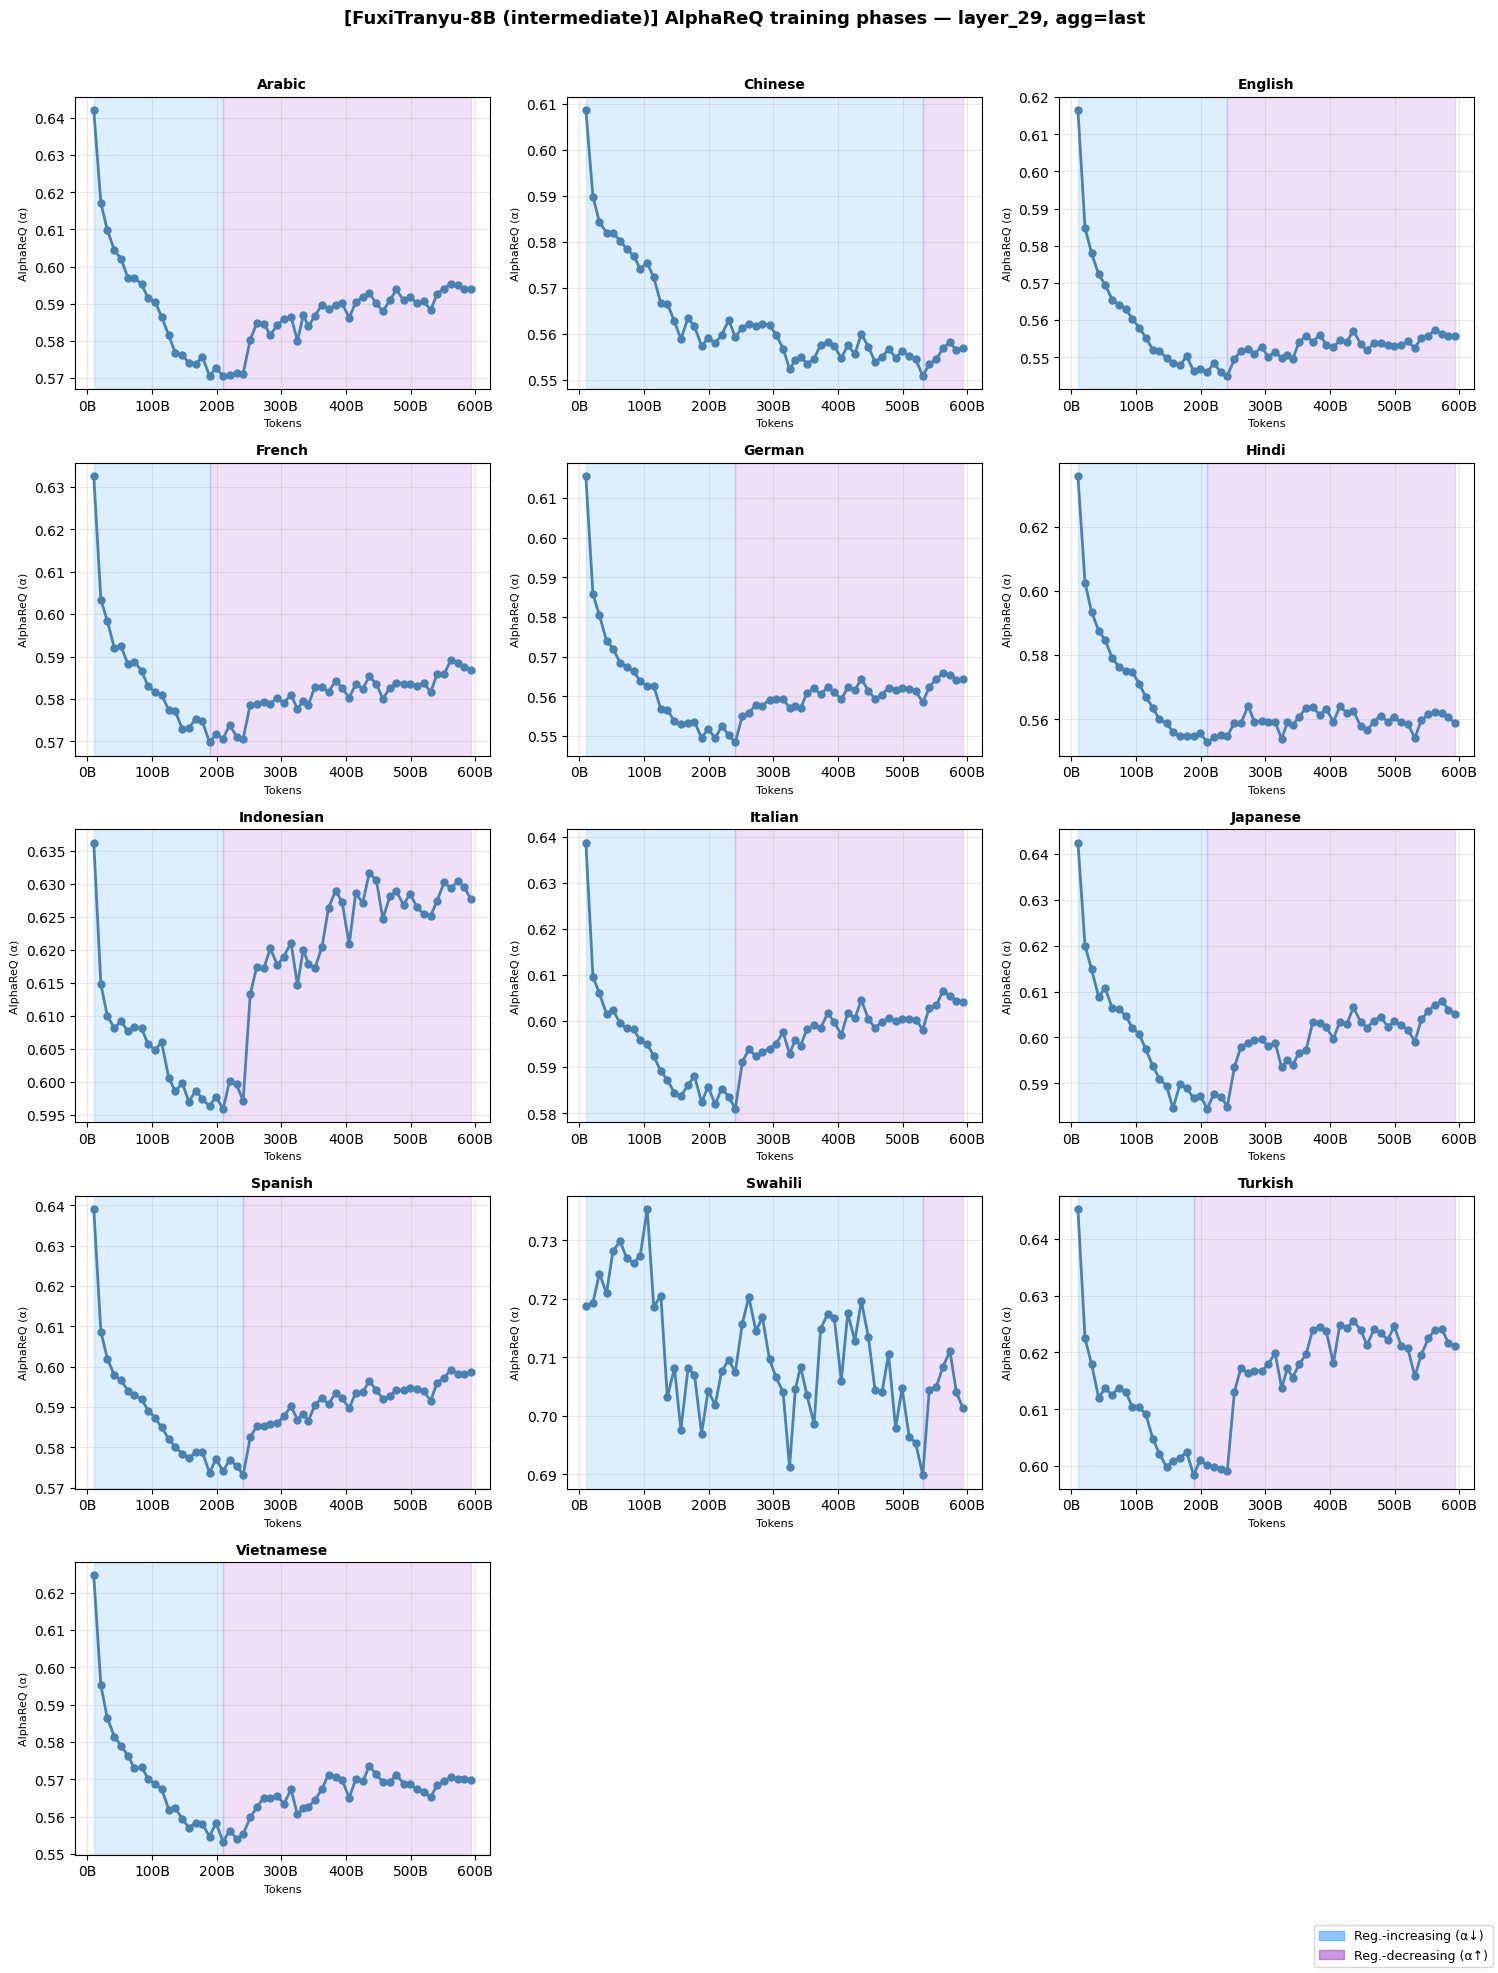

Saved: plots/alpha_phases.png


In [12]:
plot_alpha_phases(df_layer, df_alpha_phases, checkpoints_all, token_counts,
                  langs_sorted, MODEL_LABEL, LAYER, AGGREGATION, PLOTS_DIR)

### Overlay Plots (AlphaReQ)

Each panel shows AlphaReQ (blue, left axis) overlaid with downstream accuracy (red, right axis). Shaded regions mark the two α phases (blue = regularization-increasing, purple = regularization-decreasing). The black dashed line marks random-chance baseline. The purple vertical dashed line marks grokking onset where detected.

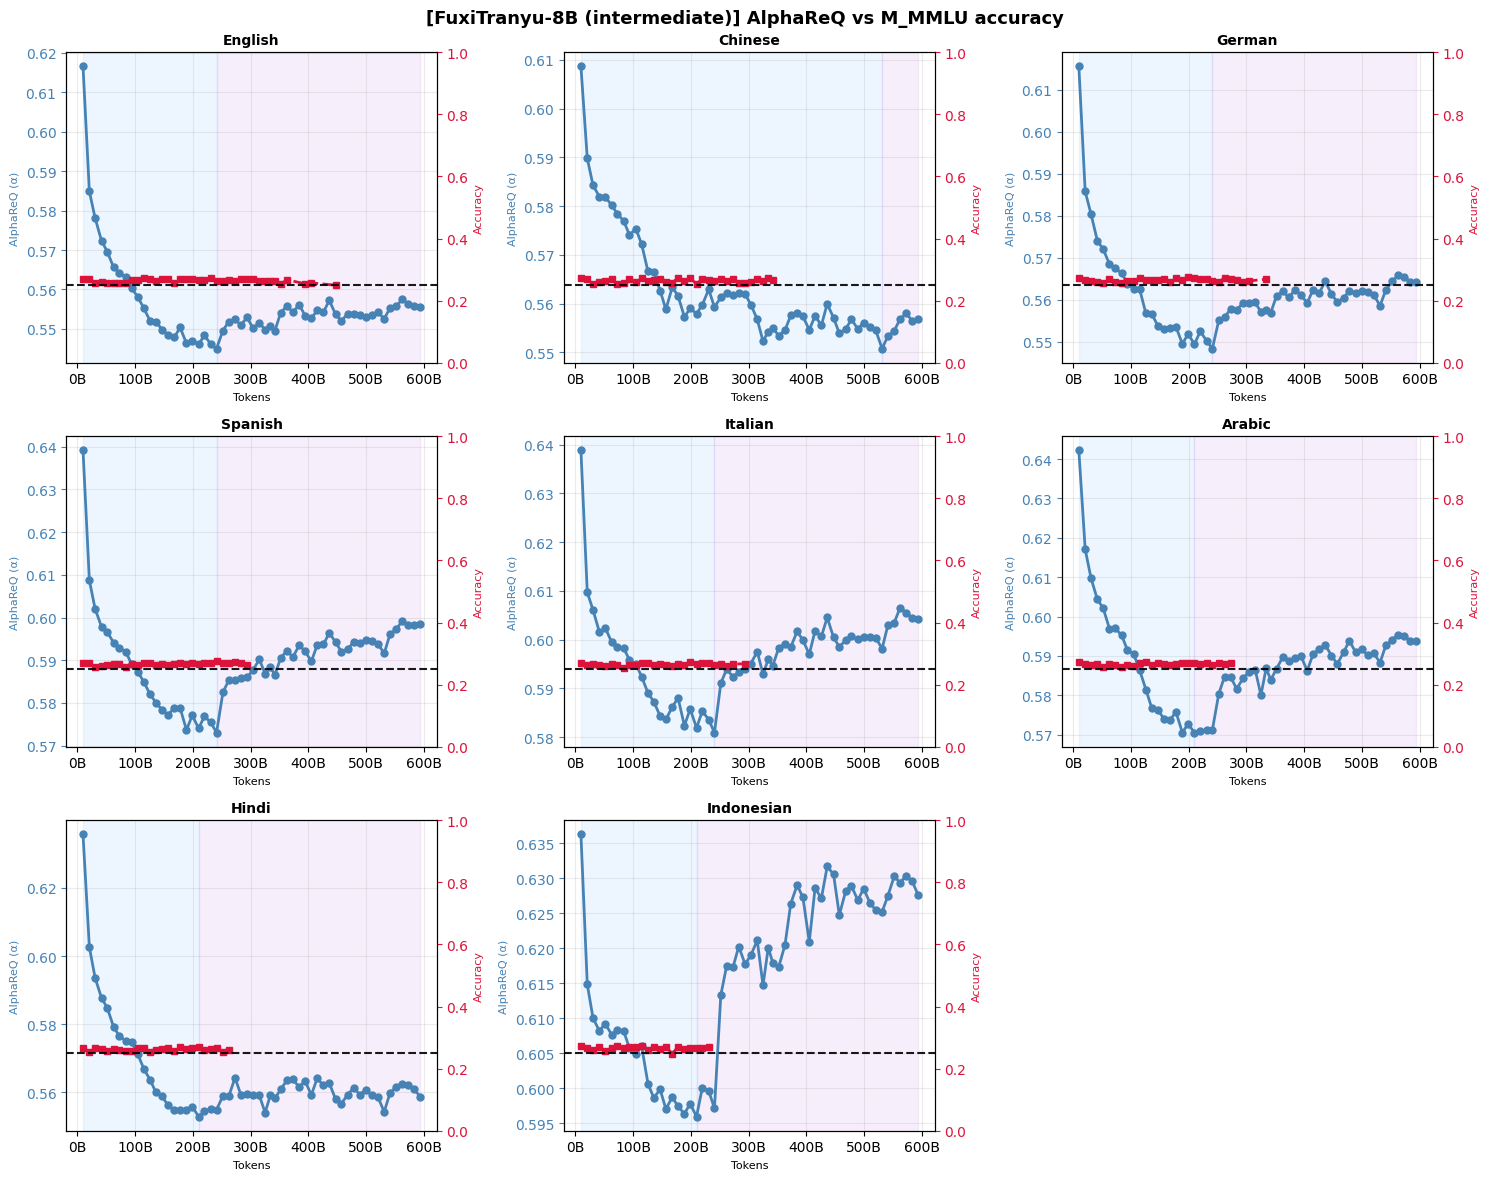

Saved: plots/alpha_overlay_m_mmlu.png


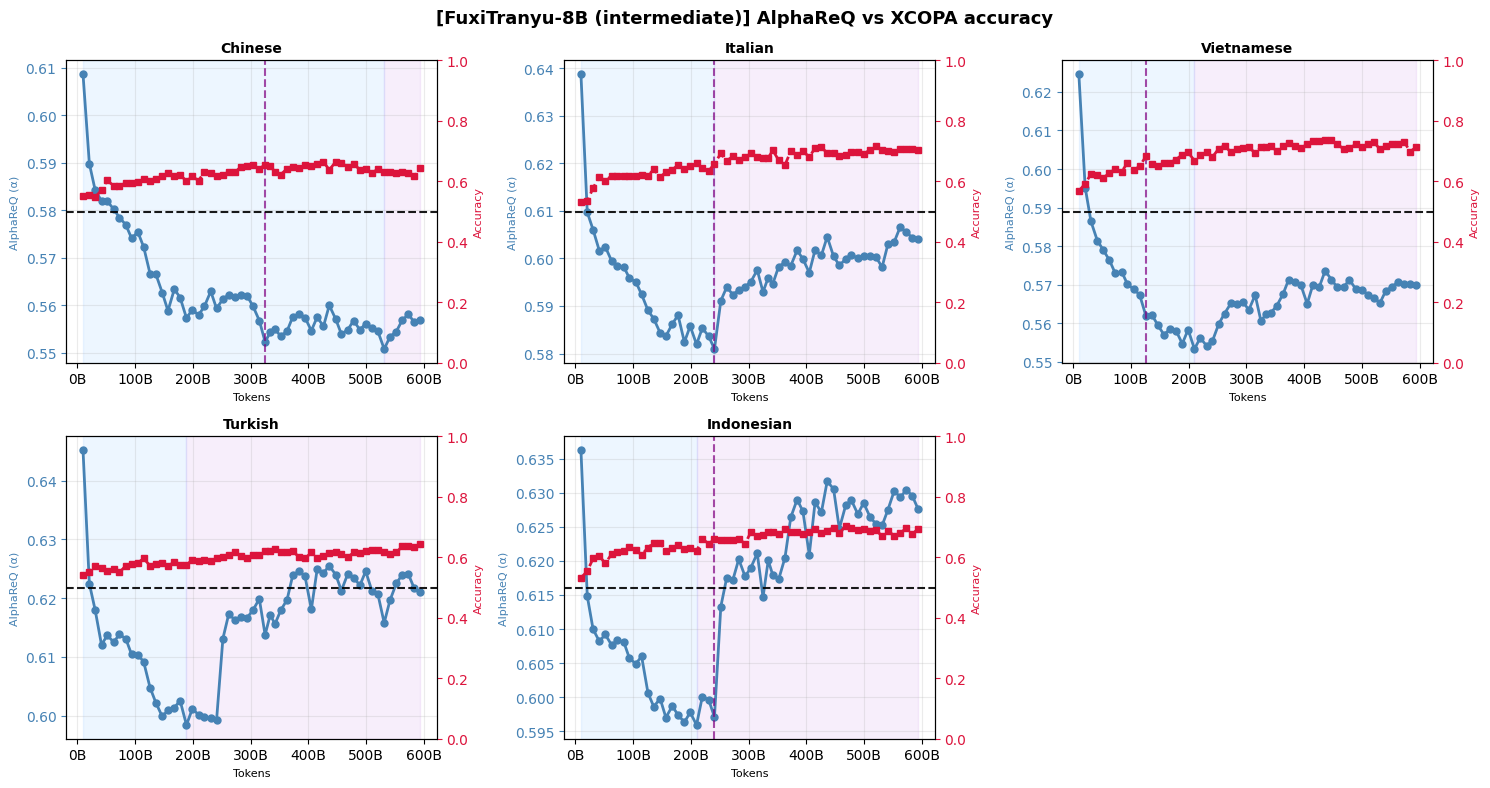

Saved: plots/alpha_overlay_xcopa.png


In [13]:
if EVAL_AVAILABLE:
    plot_alpha_overlay(df_eval, df_layer, df_alpha_phases, df_grokking, TASK_LANGUAGES,
                       RANDOM_CHANCE, checkpoints_all, token_counts, langs_sorted,
                       MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping AlphaReQ overlay plots — run evaluate.py first.")

### Correlation Analysis (AlphaReQ)

Tests whether the position of the α trough (onset of the regularization-decreasing phase) or the rate of α decline (drop in α per billion tokens during the regularization-increasing phase) predicts downstream performance. Unlike the RankMe analysis where all languages shared the same compression onset, the α trough varies across languages (189B–531B), so correlations here carry real predictive signal.

In [14]:
if EVAL_AVAILABLE and not df_grokking.empty:
    df_alpha_correlations = compute_alpha_correlations_table(df_grokking, df_alpha_phases)
    print(df_alpha_correlations.to_string(index=False))
else:
    df_alpha_correlations = pd.DataFrame()
    print("[INFO] Skipping AlphaReQ correlation analysis — no eval data available.")

  task             predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu Reg.-decreasing onset (B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu Reg.-decreasing onset (B)      Peak accuracy            8      0.2608      0.5327     0.0701     0.8691
m_mmlu   Rate of α decline (α/B) Grokking onset (B)            0         NaN         NaN        NaN        NaN
m_mmlu   Rate of α decline (α/B)      Peak accuracy            8     -0.4286      0.2894    -0.3181     0.4426
 xcopa Reg.-decreasing onset (B) Grokking onset (B)            4      0.8333      0.1667     0.7761     0.2239
 xcopa Reg.-decreasing onset (B)      Peak accuracy            5      0.2052      0.7406    -0.3450     0.5697
 xcopa   Rate of α decline (α/B) Grokking onset (B)            4     -0.9487      0.0513    -0.9787     0.0213
 xcopa   Rate of α decline (α/B)      Peak accuracy            5      0.4000      0.5046     0.5490     0.3378


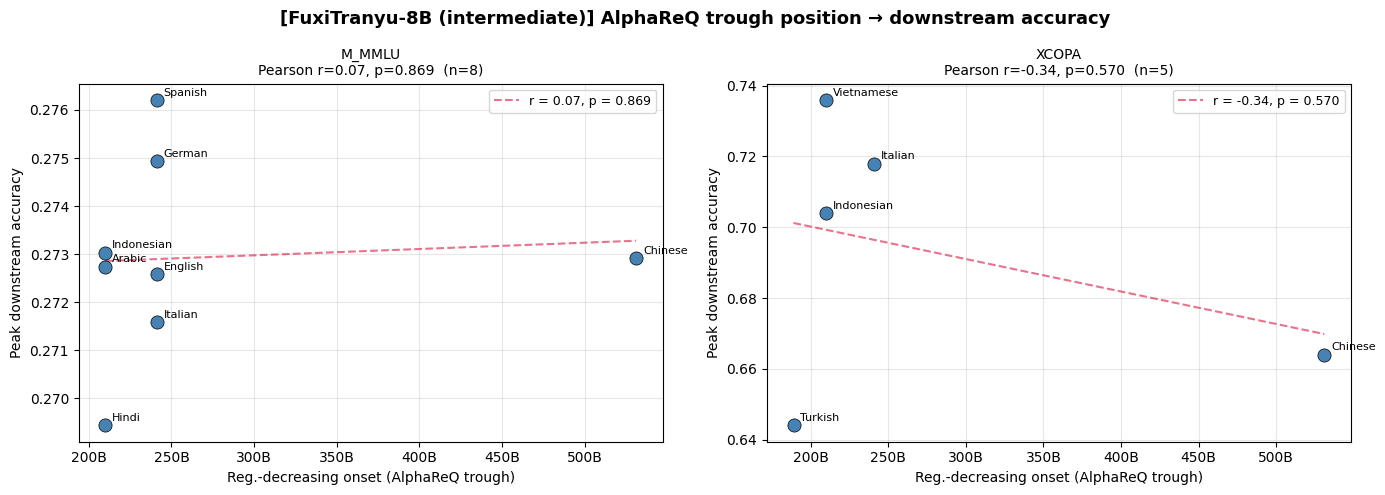

Saved: plots/alpha_correlation_scatter.png


In [15]:
if EVAL_AVAILABLE and not df_alpha_correlations.empty:
    plot_alpha_correlation_scatter(df_grokking, df_alpha_phases, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping AlphaReQ correlation scatter — no eval data available.")

### AlphaReQ Findings

**Phase structure (AlphaReQ, all 13 languages)**

- Both phases are present in every language: α falls to a trough then rises slightly, confirming the regularization-increasing → regularization-decreasing pattern is universal.
- The α trough position **varies substantially across languages** (189B–531B), in sharp contrast to RankMe where all languages peaked at 10B. Latin-script languages reach the trough early (~189–241B), while Chinese and Swahili reach it much later (~531B), suggesting these languages require more training tokens to achieve maximum self-regularization.

**Relationship with downstream accuracy (XCOPA)**

- Visually, the overlay plots suggest that α declines during the same training window where XCOPA accuracy rises, but we do not directly measure the relationship between the rate of α decline and the rate of accuracy rise. This would require derivative estimation on noisy trajectories and is left for future analysis with more languages.
- The correlation between the trough position and grokking onset is strong (Spearman r=0.83) but not statistically significant with only 4 valid pairs (p=0.17). Languages that take longer to reach peak regularization also tend to grok later — an intuitive result.
> The **rate of α decline** is a stronger predictor of grokking onset: Spearman r=−0.95 (p=0.05) and Pearson r=−0.98 (p=0.02). Languages where α drops faster during training grok earlier. This is the strongest correlation observed in the analysis, though the small sample (4 languages) means it should be interpreted with caution.
- No meaningful correlation between trough position or rate of α decline and peak accuracy is observed for XCOPA alone. With m-MMLU data across more languages, this analysis will be more conclusive.


### Workflow
```bash
# 1 — Submit one cluster job per checkpoint (see README)
for ckpt in 10B 115B ...; do
    ./downstream_evaluation/submit_eval.sh $ckpt fuxi
done

# 2 — After all jobs complete, merge once manually (see README)

# 3 — Rerun this notebook — all cells activate automatically
```